In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Гипотеза 5  Кол-во просмотров по дням недели

Kruskal-Wallis: H=612.49, p=0.0000
✅ ОТЛИЧИЯ ЗНАЧИМЫ!

Медиана просмотров по дням:
   weekday  views day_name
0        1    2.0       Пн
1        2    2.0       Вт
2        3    2.0       Ср
3        4    2.0       Чт
4        5    2.0       Пт
5        6    2.0       Сб
6        7    2.0       Вс


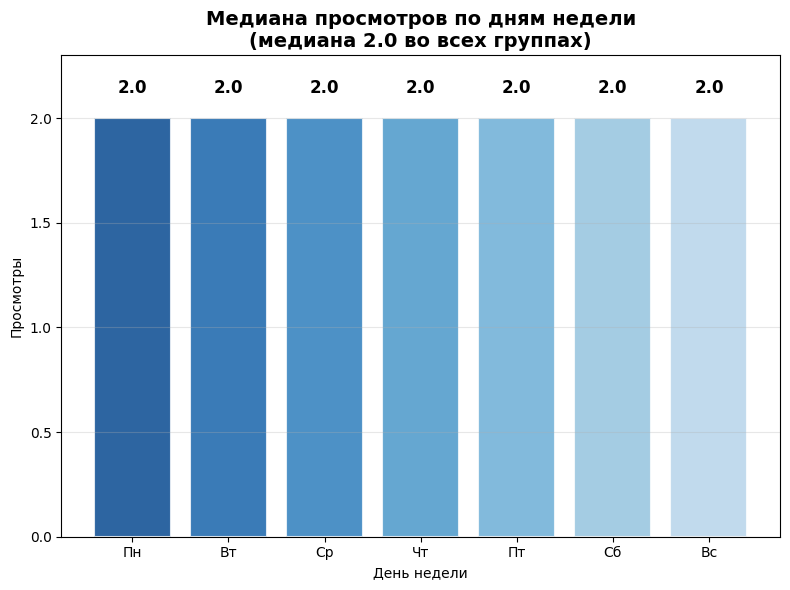

In [6]:
# Группировка по дням недели (0=Пн, 6=Вс)
weekday_views = [group['views'].values for name, group in df.groupby('weekday')]

# Kruskal-Wallis тест
stat, pval = kruskal(*weekday_views)
print(f"Kruskal-Wallis: H={stat:.2f}, p={pval:.4f}")

if pval < 0.05:
    print("✅ ОТЛИЧИЯ ЗНАЧИМЫ!")
else:
    print("❌ ОТЛИЧИЙ НЕТ")

# Медианы просмотров по дням
weekday_medians = df.groupby('weekday')['views'].median().reset_index()
weekday_medians['day_name'] = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']
weekday_medians = weekday_medians.sort_values('views', ascending=False)

print("\nМедиана просмотров по дням:")
print(weekday_medians.round(1))

# График
colors = plt.cm.Blues(np.linspace(0.9, 0.3, 7))

plt.figure(figsize=(8, 6))
bars = plt.bar(weekday_medians['day_name'], weekday_medians['views'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)

# Подписи
for bar, v in zip(bars, weekday_medians['views']):
    plt.text(bar.get_x() + bar.get_width()/2., v + 0.1, f'{v:.1f}',
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Медиана просмотров по дням недели\n(медиана 2.0 во всех группах)',
          fontweight='bold', fontsize=14)
plt.ylabel('Просмотры')
plt.xlabel('День недели')
plt.ylim(0, max(weekday_medians['views']) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hyp3_medians_gradient.png', dpi=300, bbox_inches='tight')
plt.show()

Тест Kruskal-Wallis показал статистически значимые различия между днями недели
.При этом медиана просмотров во всех днях одинакова,
поэтому различия связаны не с типичным значением, а с формой распределения:
в одни дни чаще встречаются очень короткие или, наоборот, более длинные сессии.

Вывод: день недели влияет на распределение просмотров, но не на медианный уровень.

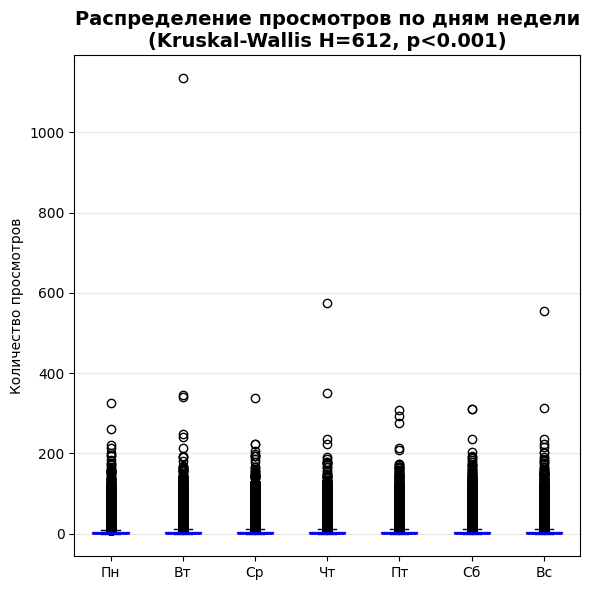

In [37]:
plt.figure(figsize=(6, 6))
box_colors = plt.cm.Blues(np.linspace(0.2, 0.8, 7))
boxplot = plt.boxplot([df[df['weekday'] == i]['views'].values for i in range(1,8)],
                      labels=weekday_medians['day_name'],
                      patch_artist=True,
                      medianprops=dict(color='blue', linewidth=2))

# Окраска боксов градиентом
for patch, color in zip(boxplot['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Распределение просмотров по дням недели\n(Kruskal-Wallis H=612, p<0.001)',
          fontweight='bold', fontsize=14)
plt.ylabel('Количество просмотров')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hyp3_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

Чтобы визуализировать распределения, удалим выбросы (аномально большие значения просмотров)

Убрано выбросов: 329,257
Удалено: 329257 записей (7.9%)


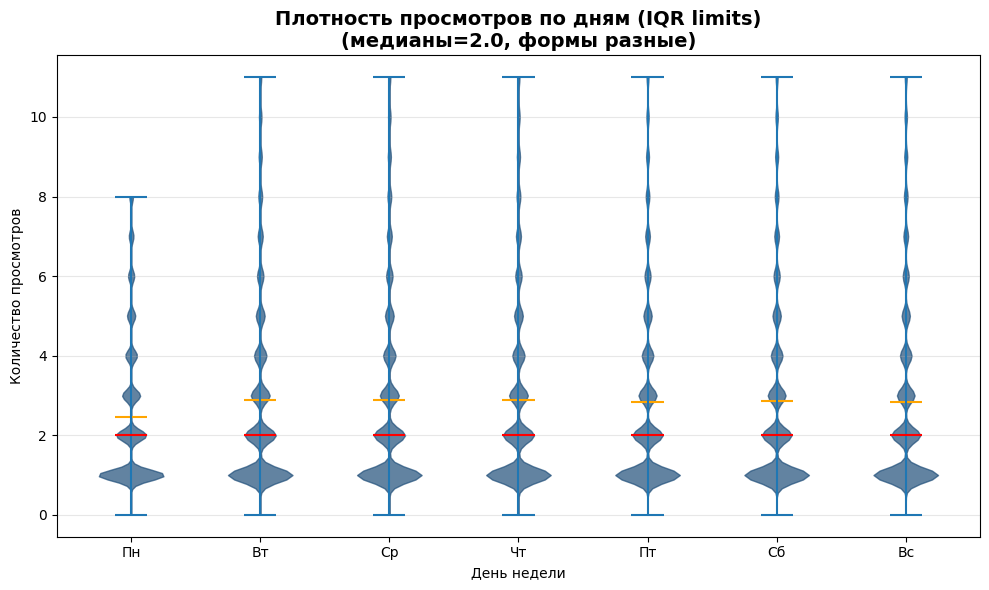

In [43]:
# Функция обрезки по IQR
def clip_outliers(group):
    Q1 = group['views'].quantile(0.25)
    Q3 = group['views'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['views'] >= lower) & (group['views'] <= upper)]

# Обрезаем выбросы для каждого дня
df_clipped = df.groupby('weekday', group_keys=False).apply(clip_outliers, include_groups=True)
print(f"Убрано выбросов: {len(df) - len(df_clipped):,}")
print(f"Удалено: {len(df) - len(df_clipped)} записей ({100 * (1 - len(df_clipped)/len(df)):.1f}%)")

plt.figure(figsize=(10, 6))
violin_data = [df_clipped[df_clipped['weekday'] == i]['views'].values for i in range(1,8)]

parts = plt.violinplot(violin_data, positions=range(1,8), showmeans=True, showmedians=True)

dark_blue = '#1f4e79'
for pc in parts['bodies']:
    pc.set_facecolor(dark_blue)
    pc.set_alpha(0.7)
    pc.set_edgecolor(dark_blue)

parts['cmedians'].set_color('red')
parts['cmeans'].set_color('orange')

plt.xticks(range(1,8), weekday_medians['day_name'])
plt.title('Плотность просмотров по дням (IQR limits)\n(медианы=2.0, формы разные)',
          fontweight='bold', fontsize=14)
plt.ylabel('Количество просмотров')
plt.xlabel('День недели')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hyp3_violin_clean.png', dpi=300, bbox_inches='tight')
plt.show()

Проведение пост-хок тестов нецелесообразно, так как даже при подтверждении различий между конкретными днями (например, понедельник vs остальные), эффект не имеет бизнес-значимости. Разница в "хвостах" распределения не меняет стратегию контента или рекламных активностей, так как 50% пользователей (медиана) ведут себя одинаково в любой день. Что еще более наглядно видно на просмотрах тех, кто совершил покупки. Распределения еще более похожи между собой, медианы одинаковы, но тесты обнаруживают различия.

In [44]:
# Только сессии с покупкой
df_buyers = df[df['made_purchase'] == 1]

buyer_medians = df_buyers.groupby('weekday')['views'].median().reset_index()
buyer_medians['day_name'] = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

print("Медиана просмотров ПОКУПАТЕЛЕЙ:")
print(buyer_medians.round(1))

# Kruskal-Wallis для покупателей
buyer_groups = [df_buyers[df_buyers['weekday'] == i]['views'].values for i in range(1,8)]
stat_buy, p_buy = kruskal(*buyer_groups)
print(f"\nKruskal-Wallis (покупатели): H={stat_buy:.1f}, p={p_buy:.4f}")

=== ПРОСМОТРЫ ТОЛЬКО ПОКУПАТЕЛЕЙ по дням ===
Медиана просмотров ПОКУПАТЕЛЕЙ:
   weekday  views day_name
0        1    3.0       Пн
1        2    3.0       Вт
2        3    3.0       Ср
3        4    3.0       Чт
4        5    3.0       Пт
5        6    3.0       Сб
6        7    3.0       Вс

Kruskal-Wallis (покупатели): H=113.8, p=0.0000


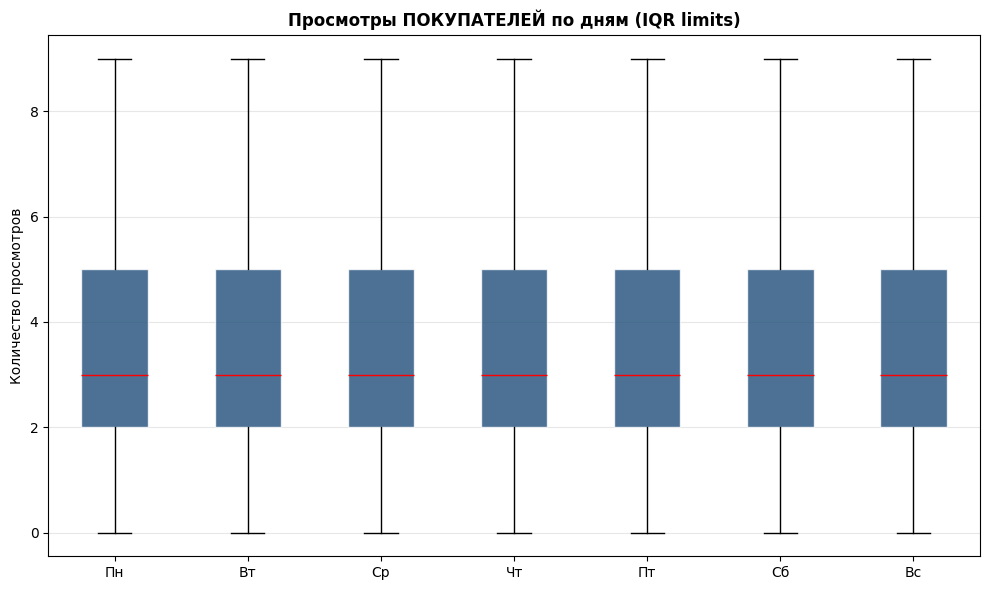

In [49]:
# Boxplot покупателей
plt.figure(figsize=(10, 6))
buyer_box_data = [df_buyers_clipped[df_buyers_clipped['weekday'] == i]['views'].values
                  for i in range(1,8)]

boxplot = plt.boxplot(buyer_box_data, labels=buyer_medians['day_name'],
                      patch_artist=True, showfliers=False)

dark_blue = '#1f4e79'
for patch in boxplot['boxes']:
    patch.set_facecolor(dark_blue)
    patch.set_alpha(0.8)
    patch.set_edgecolor('white')

for median in boxplot['medians']:
    median.set_color('red')

plt.title('Просмотры ПОКУПАТЕЛЕЙ по дням (IQR limits)', fontweight='bold')
plt.ylabel('Количество просмотров')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('hyp3_buyers_boxplot.png', dpi=300)
plt.show()